# Regressió

Aquest notebook conté exemples simples però complets d'alguns dels distints tipus de regressió que podem fer.

Utilitzarem dades sintètiques perquè no ens interessa tant el problema com la distribució de les dades, els algorismes i l'avaluació dels models.

Suposen un problema molt simple en el que tenim el àrea d'unes cases i el seu preu:


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame([[2600,550000],[3000,565000],[3200,610000],[3600,680000],[4000,725000]],columns=["area","precio"])
df

,area,precio
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


Si els representem en un `Scatterplot` veurem com formen una lína aproximada que podem representar amb una recta. Però quina és la recta més ajustada?:

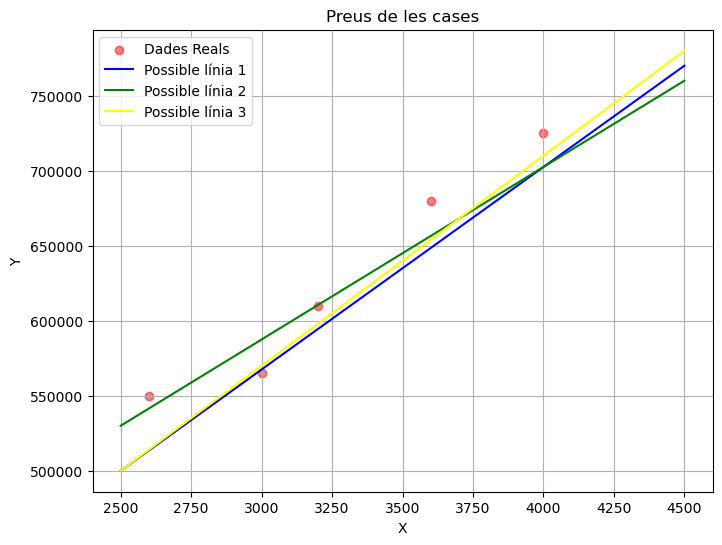

In [14]:
plt.figure(figsize=(8, 6))  # Crear una figura amb una grandària específica
plt.scatter(df["area"], df["precio"], color='red', alpha=0.5, label="Dades Reals")  # Graficar els punts de dades originals
plt.plot([2500,4500], [500000,770000], color="blue", label="Possible línia 1") 
plt.plot([2500,4500], [530000,760000], color="green", label="Possible línia 2") 
plt.plot([2500,4500], [500000,780000], color="yellow", label="Possible línia 3") 
plt.title("Preus de les cases")  # Títol del gràfic
plt.xlabel("X")  # Etiqueta de l'eix X
plt.ylabel("Y")  # Etiqueta de l'eix Y
plt.legend()  # Mostrar la llegenda
plt.grid()  # Afegir una quadrícula
plt.show()  # Mostrar el gràfic

No té sentit fer-ho a ull, encara que intuitivament podem dibuixar una línia amb l'inclinació adequada. 

Si fem una regressió lineal deguem trobar la lína que tinga aquesta fórmula:

$$preu=m*area+b$$

* **m** és es gradient o `coef_`
* **b** és l'`intercept_`


In [29]:
X = df.drop("precio",axis=1)
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit(X.values,df.precio.values)

LinearRegression()

In [30]:
reg.predict([[3000]])

array([587979.45205479])

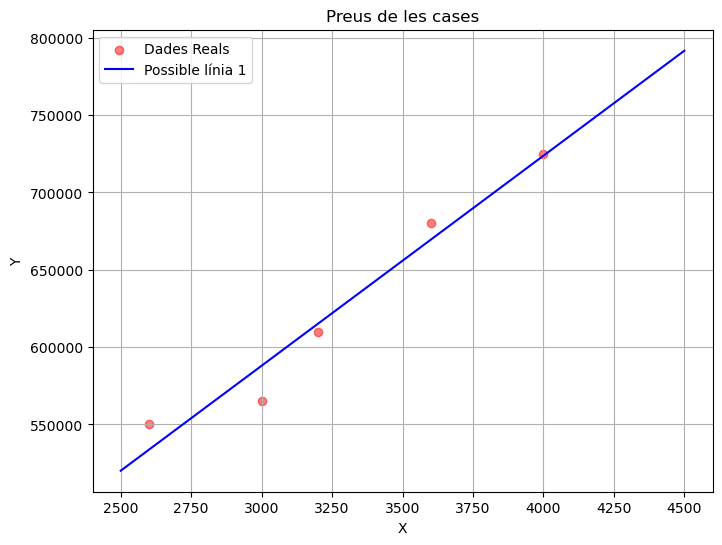

In [31]:
plt.figure(figsize=(8, 6))  # Crear una figura amb una grandària específica
plt.scatter(df["area"], df["precio"], color='red', alpha=0.5, label="Dades Reals")  # Graficar els punts de dades originals
plt.plot([2500,4500], [reg.predict([[2500]])[0],reg.predict([[4500]])[0]], color="blue", label="Possible línia 1") 
plt.title("Preus de les cases")  # Títol del gràfic
plt.xlabel("X")  # Etiqueta de l'eix X
plt.ylabel("Y")  # Etiqueta de l'eix Y
plt.legend()  # Mostrar la llegenda
plt.grid()  # Afegir una quadrícula
plt.show()  # Mostrar el gràfic

## Regressió lineal

Aquest codi implementa i avalua un model de regressió lineal usant dades generades artificialment. Resum dels passos clau:

1. Importació de biblioteques
S'importen les biblioteques necessàries: numpy i pandes per a maneig de dades, sklearn per al model i mètriques, i matplotlib per a visualització.
2. Generació de dades sintètiques
Es creen dades X en un rang uniforme entre -3 i 3.
Es genera
i seguint una relació lineal
y = 4X^2 amb soroll aleatori (N(0,1),
N(0,1)) per simular dades no perfectament lineals.
3. Divisió de dades
Les dades es divideixen en dos conjunts: entrenament (80%) i prova (20%), fent servir train_test_split. Això assegura que el model s'entrene en un subconjunt i s'avalue en un altre d'independent.
4. Entrenament del model
Es crea un model de regressió lineal (LinearRegression) i s'entrena amb les dades d'entrenament (X_train, y_train) mitjançant el mètode .fit().
5. Prediccions
Es generen prediccions (i_pred) sobre les dades de prova (X_test) usant .predict().
6. Avaluació del model
Es calculen dues mètriques de desenvolupament:
Error Quadràtic Mitjà (MSE): Mesura l'error mitjà de les prediccions.
Coeficient de Determinació (R²): Avalua què tan bé el model explica la variabilitat de les dades.
7. Visualització
Es grafiquen:
Les dades originals (punts blaus).
La línia ajustada pel model (línia vermella), usant prediccions sobre un rang continu de X.
8. Resultats
S'imprimeixen els paràmetres del model:
Intercepte (β₀): Valor d'i quan X=0.
Coeficient (β₁): Pendent de la recta.
S'imprimeixen les mètriques de desenvolupament (MSE i R2).


En resum, el codi genera dades sintètiques amb una relació lineal sorollosa, entrena un model de regressió lineal, n'avalua l'exercici i visualitza l'ajust en una gràfica. És un exemple clàssic per introduir-hi la regressió lineal i la seva interpretació.

Equació utilitzada per a la generació de dades: y = 4X - 2 + soroll
Equació del model: y = 3.9331X + -2.0578

Exemples de dades (conjunt d'entrenament):
   X_entrenament  y_entrenament
0       2.531245       8.193545
1       2.323276       8.256482
2      -1.801957      -9.550544
3      -2.793669     -12.031853
4       2.921322      10.467109

Prediccions amb diferències (conjunt de prova):
    X_prova     y_real  y_predicció  Diferència
0 -2.618650 -11.818046   -12.357196    0.539150
1  2.368964   6.972381     7.259628   -0.287248
2  1.633469   3.296924     4.366845   -1.069922
3  0.975134   0.991147     1.777543   -0.786396
4 -1.447320  -6.998248    -7.750229    0.751981

--------------------------------------------------



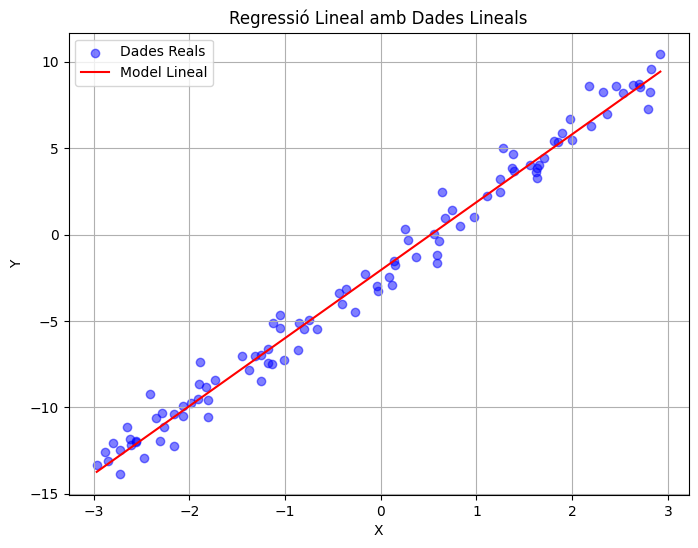

Gràfica: Ajust del model de regressió lineal a les dades reals.

Mètriques del Model Lineal:
  MSE: 0.6537
  RMSE: 0.8085
  R²: 0.9880


In [9]:
# Importar les biblioteques necessàries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generar dades lineals amb soroll
np.random.seed(42)  # Fixar una llavor per al generador de nombres aleatoris per a fer-lo reproducible
X = np.random.uniform(-3, 3, size=(100, 1))  # Generar valors uniformes entre -3 i 3
y = 4 * X - 2 + np.random.normal(0, 1, size=X.shape)  # Generar dades seguint una funció lineal + soroll.

print("Equació utilitzada per a la generació de dades: y = 4X - 2 + soroll")

#print(X,y)

# Dividir les dades en conjunts d'entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # 80% per a entrenament, 20% per a prova

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


# Crear un model de regressió lineal
model = LinearRegression()
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

# Ajustar el model a les dades d'entrenament
model.fit(X_train, y_train)

# Generar prediccions amb les dades de prova
y_pred = model.predict(X_test)

# Avaluar el model utilitzant mètriques
mse = mean_squared_error(y_test, y_pred)  # Calcular l'Error Quadràtic Mitjà (MSE)
rmse = np.sqrt(mse)  # Calcular l'Arrel de l'Error Quadràtic Mitjà (RMSE)
r2 = r2_score(y_test, y_pred)  # Calcular el Coeficient de Determinació (R²)

# Imprimir l'equació resultant del model
intercept = model.intercept_[0]  # Obtenir el terme independent (intercepta)
coefficient = model.coef_[0][0]  # Obtenir el coeficient de la variable X
print(f"Equació del model: y = {coefficient:.4f}X + {intercept:.4f}")

# Mostrar alguns registres de dades i les seves prediccions
print("\nExemples de dades (conjunt d'entrenament):")
train_sample = np.hstack((X_train[:5], y_train[:5]))
train_df = pd.DataFrame(train_sample, columns=["X_entrenament", "y_entrenament"])
print(train_df)

print("\nPrediccions amb diferències (conjunt de prova):")
test_sample = np.hstack((X_test[:5], y_test[:5], y_pred[:5]))  # Combinar X_test, y_test i y_pred
test_df = pd.DataFrame(test_sample, columns=["X_prova", "y_real", "y_predicció"])
test_df["Diferència"] = test_df["y_real"] - test_df["y_predicció"]  # Calcular les diferències
print(test_df)

# Salt de línia:
print("\n" + "-" * 50 + "\n")

# Visualitzar les dades reals i la línia ajustada del model
plt.figure(figsize=(8, 6))  # Crear una figura amb una grandària específica
plt.scatter(X, y, color='blue', alpha=0.5, label="Dades Reals")  # Graficar els punts de dades originals
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)  # Crear un rang continu de valors X
y_range_pred = model.predict(X_range)  # Preveure valors de Y per al rang continu de X
plt.plot(X_range, y_range_pred, color="red", label="Model Lineal")  # Graficar la línia del model
plt.title("Regressió Lineal amb Dades Lineals")  # Títol del gràfic
plt.xlabel("X")  # Etiqueta de l'eix X
plt.ylabel("Y")  # Etiqueta de l'eix Y
plt.legend()  # Mostrar la llegenda
plt.grid()  # Afegir una quadrícula
plt.show()  # Mostrar el gràfic

# Afegir un títol per a presentar el contingut de la gràfica
print("Gràfica: Ajust del model de regressió lineal a les dades reals.")

# Mostrar mètriques de rendiment del model
print("\nMètriques del Model Lineal:")
print(f"  MSE: {mse:.4f}")  # Imprimir l'MSE amb 4 decimals
print(f"  RMSE: {rmse:.4f}")  # Imprimir l'RMSE amb 4 decimals
print(f"  R²: {r2:.4f}")  # Imprimir l'R² amb 4 decimals


## Regressió lineal amb dades no lineals

Al següent exemple s'aborda la limitació dels models de regressió lineal en intentar ajustar dades amb relacions no lineals. Es generen dades sintètiques seguint un polinomi de grau 3 amb soroll afegint un soroll segons una funció sinusoïdal (sinus i cosinus) i valors entre 0 i 10, representant una relació cúbica complexa entre la variable independent (
X
X) i la variable dependent (
i
i). Posteriorment s'entrena un model de regressió lineal sobre aquestes dades.

L'objectiu és analitzar com un model lineal no aconsegueix capturar adequadament la naturalesa no lineal de les dades, cosa que s'evidencia tant a les mètriques d'acompliment (baix
R
2
R
2
) com en la visualització del model ajustat. Aquest exemple il·lustra la necessitat de fer servir models més avançats, com ara regressions polinòmiques o tècniques no lineals, per a dades amb relacions complexes.

Equació utilitzada per a generar les dades: y = 3X³ - 2X² + 5sin(5X) + 2cos(3X) + soroll
Equació obtinguda pel model: y = 16.4018X + -5.6180

Exemples de dades utilitzades per a l'entrenament:
   X_entrenament  y_entrenament
0       2.531245      37.489148
1       2.323276      33.938691
2      -1.801957     -28.211854
3      -2.793669     -75.526073
4       2.921322      68.422836

Prediccions en el conjunt de prova amb diferències:
    X_prova     y_real  y_predicció  Diferència
0 -2.618650 -63.538063   -48.568624  -14.969439
1  2.368964  21.681343    33.237357  -11.556014
2  1.633469   0.499749    21.173887  -20.674138
3  0.975134 -15.100864    10.375992  -25.476856
4 -1.447320 -10.175427   -29.356676   19.181249

--------------------------------------------------



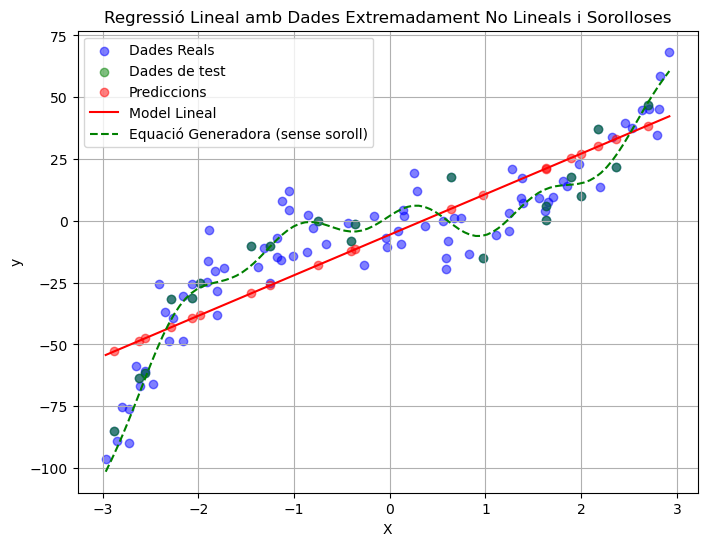

Gràfic: Ajust del model de regressió lineal a les dades reals (dades altament no lineals i sorolloses).

Mètriques del Model Lineal:
  MSE: 248.2732
  RMSE: 15.7567
  R²: 0.7662


In [8]:
# Importar les biblioteques necessàries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generar dades altament no lineals i extremadament sorolloses
np.random.seed(42)  # Fixar una llavor per a la reproductibilitat
X = np.random.uniform(-3, 3, size=(100, 1))  # Generar valors uniformes entre -3 i 3

# Introduir termes complexos no lineals amb soroll significatiu
y = 3 * X**3 - 2 * X**2 + 5 * np.sin(5 * X) + 2 * np.cos(3 * X) + np.random.normal(0, 10, size=X.shape)

# Imprimir l'equació utilitzada per a generar les dades
print("Equació utilitzada per a generar les dades: y = 3X³ - 2X² + 5sin(5X) + 2cos(3X) + soroll")

# Dividir les dades en conjunts d'entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # 80% entrenament, 20% prova

# Crear un model de regressió lineal
model = LinearRegression()

# Ajustar el model amb les dades d'entrenament
model.fit(X_train, y_train)

# Generar prediccions sobre el conjunt de prova
y_pred = model.predict(X_test)

# Avaluar el model usant mètriques
mse = mean_squared_error(y_test, y_pred)  # Calcular l'Error Quadràtic Mitjà (MSE)
rmse = np.sqrt(mse)  # Calcular l'Arrel de l'Error Quadràtic Mitjà (RMSE)
r2 = r2_score(y_test, y_pred)  # Calcular el Coeficient de Determinació (R²)

# Imprimir l'equació completa de la línia de regressió obtinguda pel model
intercept = model.intercept_[0]  # Obtenir la intercepció
coefficient = model.coef_[0][0]  # Obtenir el coeficient
print(f"Equació obtinguda pel model: y = {coefficient:.4f}X + {intercept:.4f}")

# Mostrar alguns registres d'entrenament i prediccions del model
print("\nExemples de dades utilitzades per a l'entrenament:")
train_sample = np.hstack((X_train[:5], y_train[:5]))  # Combinar X i y d'entrenament per a visualització
train_df = pd.DataFrame(train_sample, columns=["X_entrenament", "y_entrenament"])
print(train_df)

print("\nPrediccions en el conjunt de prova amb diferències:")
test_sample = np.hstack((X_test[:5], y_test[:5], y_pred[:5]))  # Combinar X_test, y_test i y_pred
test_df = pd.DataFrame(test_sample, columns=["X_prova", "y_real", "y_predicció"])
test_df["Diferència"] = test_df["y_real"] - test_df["y_predicció"]  # Calcular diferències
print(test_df)

# Afegir un salt de línia abans del gràfic
print("\n" + "-" * 50 + "\n")

# Visualitzar les dades reals i la línia ajustada
plt.figure(figsize=(8, 6))  # Crear una figura amb una grandària específica
plt.scatter(X, y, color='blue', alpha=0.5, label="Dades Reals")  # Graficar els punts de dades originals
plt.scatter(X_test, y_test, color='green', alpha=0.5, label="Dades de test")  # Graficar els punts
plt.scatter(X_test, y_pred, color='red', alpha=0.5, label="Prediccions")  # Graficar els punts de predicció
# Reutilitzar X_range del primer gràfic
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) 
y_range_pred = model.predict(X_range)  # Preveure valors de Y per al rang continu
plt.plot(X_range, y_range_pred, color="red", label="Model Lineal")  # Graficar la línia del model
y_generated_range = 3 * X_range**3 - 2 * X_range**2 + 5 * np.sin(5 * X_range) + 2 * np.cos(3 * X_range)
plt.plot(X_range, y_generated_range, color='green', linestyle='--', label='Equació Generadora (sense soroll)')
plt.title("Regressió Lineal amb Dades Extremadament No Lineals i Sorolloses")  # Títol del gràfic
plt.xlabel("X")  # Etiqueta de l'eix X
plt.ylabel("y")  # Etiqueta de l'eix Y
plt.legend()
plt.grid()
plt.show()

# Afegir un títol per a presentar el contingut del gràfic
print("Gràfic: Ajust del model de regressió lineal a les dades reals (dades altament no lineals i sorolloses).")

# Mostrar mètriques de rendiment
print("\nMètriques del Model Lineal:")
print(f"  MSE: {mse:.4f}")  # Imprimir l'MSE amb 4 decimals
print(f"  RMSE: {rmse:.4f}")  # Imprimir l'RMSE amb 4 decimals
print(f"  R²: {r2:.4f}")  # Imprimir l'R² amb 4 decimals


## Regressió polinòmica

El codi següent explora l'ús de regressió polinòmica per modelar relacions no lineals. S'utilitzen les mateixes dades sintètiques de l'exercici anterior que no es podien modelar amb una regressió lineal.

S'entrenen models de graus 1 a 5. Per a cada grau es calculen mètriques com
MSE,
RMSE i
R
2
, i es visualitzen els ajustaments en gràfiques. Finalment, una taula resumeix els resultats, destacant el model amb el millor exercici, equilibrant ajustament i generalització.

Equació utilitzada per a generar les dades: y = 3X³ - 2X² + 5sin(5X) + 2cos(3X) + soroll


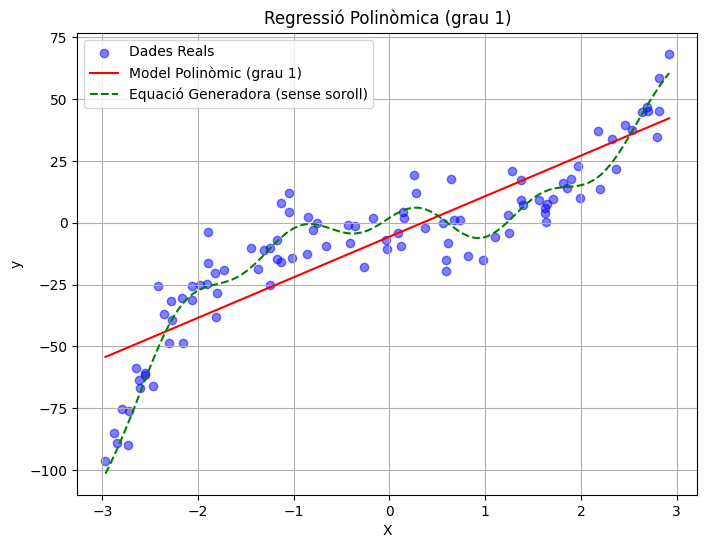

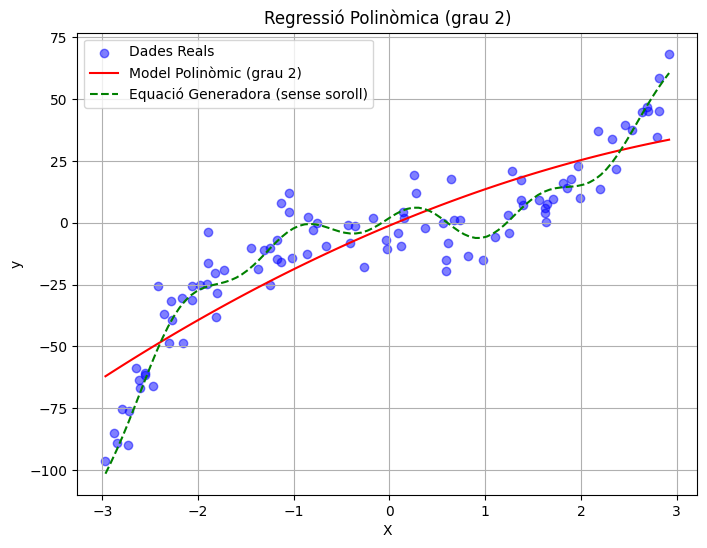

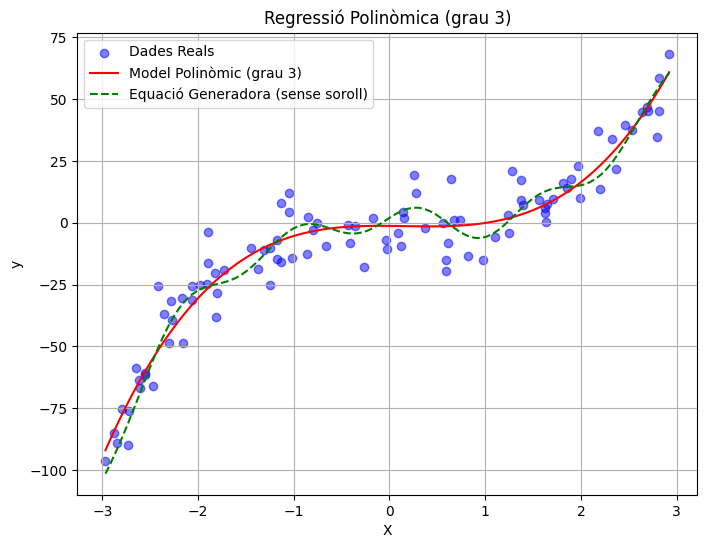

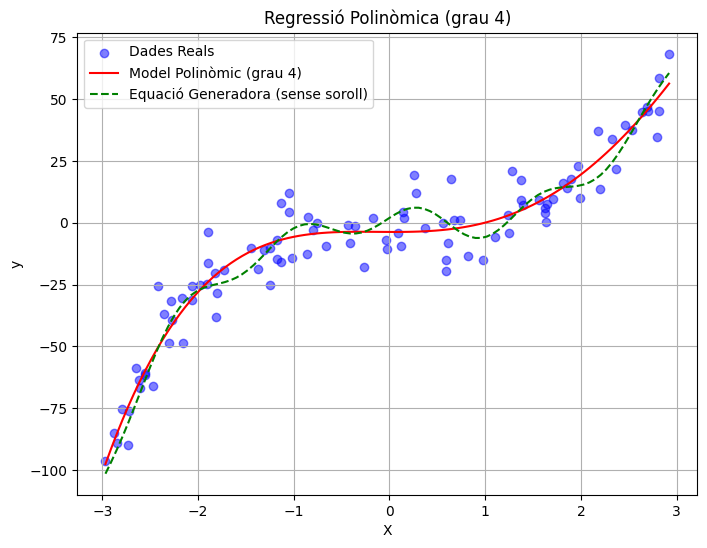

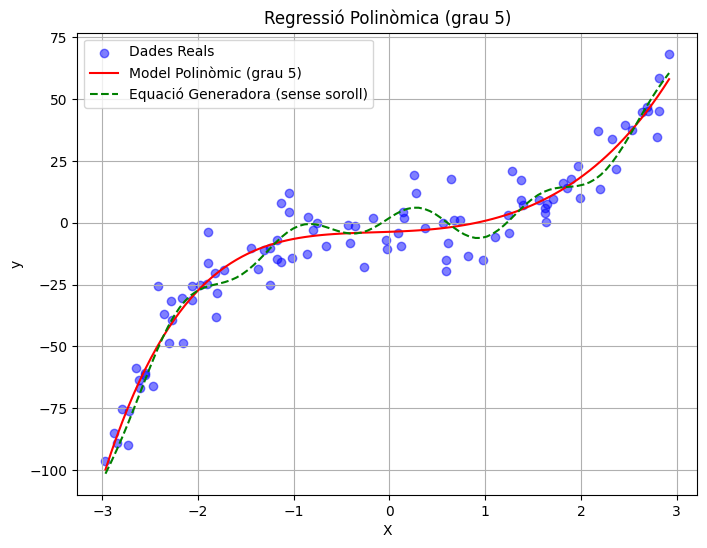


Resultats dels models de regressió polinòmica (ordenats per R²):
 Grau        MSE      RMSE       R²
    3  61.090895  7.816066 0.942471
    5  61.637941  7.850983 0.941956
    4  62.967623  7.935214 0.940704
    2 212.026983 14.561146 0.800336
    1 248.273153 15.756686 0.766203


In [11]:
# Importar les biblioteques necessàries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generar dades altament no lineals i extremadament sorolloses
np.random.seed(42)  # Fixar una llavor per a la reproductibilitat
X = np.random.uniform(-3, 3, size=(100, 1))  # Generar valors uniformes entre -3 i 3

# Introduir termes complexos no lineals amb soroll significatiu
y = 3 * X**3 - 2 * X**2 + 5 * np.sin(5 * X) + 2 * np.cos(3 * X) + np.random.normal(0, 10, size=X.shape)

# Imprimir l'equació utilitzada per a generar les dades
print("Equació utilitzada per a generar les dades: y = 3X³ - 2X² + 5sin(5X) + 2cos(3X) + soroll")

# Dividir les dades en conjunts d'entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # 80% entrenament, 20% prova

# Provar diferents graus de polinomis
degrees = [1, 2, 3, 4, 5]  # Graus a avaluar
results = []  # Llista per a emmagatzemar els resultats de cada grau

for degree in degrees:
    # Transformar les característiques amb PolynomialFeatures
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Crear i entrenar el model de regressió lineal
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Generar prediccions en el conjunt de prova
    y_pred = model.predict(X_test_poly)

    # Calcular mètriques finals en el conjunt de prova
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Emmagatzemar els resultats
    results.append((degree, mse, rmse, r2))

    # Graficar el model de cada grau
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range_pred = model.predict(X_range_poly)

    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color='blue', alpha=0.5, label="Dades Reals")
    plt.plot(X_range, y_range_pred, color="red", label=f"Model Polinòmic (grau {degree})")

    y_generated_range = 3 * X_range**3 - 2 * X_range**2 + 5 * np.sin(5 * X_range) + 2 * np.cos(3 * X_range)
    plt.plot(X_range, y_generated_range, color='green', linestyle='--', label='Equació Generadora (sense soroll)')
    plt.title(f"Regressió Polinòmica (grau {degree})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid()
    plt.show()

# Crear un DataFrame amb els resultats i ordenar-los per R² de prova
results_df = pd.DataFrame(results, columns=["Grau", "MSE", "RMSE", "R²"]).sort_values(by="R²", ascending=False)

# Imprimir els resultats ordenats
print("\nResultats dels models de regressió polinòmica (ordenats per R²):")
print(results_df.to_string(index=False))  # Mostrar taula completa sense truncar


## KneighborsRegressor

El planteamiento básico de muchos modelos de clasificación se puede utilizar para un modelo de regre-
sión. Así es para un modelo de clasificación k-NN. Tanto para un modelo de clasificación como para uno de
regresión, se consideran las k observaciones más cercanas para la predicción del atributo target. Para un mo-
delo de clasificación, la predicción es el valor del atributo target más frecuente entre ellas. Para uno de re-
gresión, la predicción es la media aritmética de los valores del atributo target para ellas.
El código para un modelo de regresión, que se da a continuación, es muy similar. Las diferencias son las
siguientes:
•En lugar de KNeighborsClassifier, se utiliza KneighborsRegressor. El atributo
target es un atributo numérico, petal_length, en lugar de uno categórico (class).
•Se obtiene una métrica para el ajuste del modelo propia de un modelo de regresión, el coeficien-
te de determinación R2, r2_score.
•Una línea negra representa el valor predicho por el modelo para cada valor del atributo predic-
tor. Para ello, se obtienen las predicciones para los valores entre los valores mínimo y máximo
del atributo predictor (np.min(x['petal_width'] y np.max(x['petal_width']),
con un intervalo entre valores de 10 -3. El método predict necesita que cada dato esté en una
fila. Por ello se utiliza reshape(-1, 1).
Método reshape(filas, columnas) de NumPy
Este método permite obtener un array que es el resultado de reacomodar los elementos de un
array a una nueva forma. Por ejemplo, si arr es un array de 4 filas por 3 columnas, es decir,
que tiene 12 elementos, arr.reshape(2, 6) devolverá un array con 2 filas por 6 colum-
nas.
Si se especifica el valor -1 para el número de filas (o de columnas), este se calculará dividiendo
el número de elementos del array por el número de columnas (o de filas) dado. En el ejemplo
que sigue, el resultado de reshape(-1, 1) aplicado a un array de una fila por n columnas
(por tanto, con n elementos) será un array con los mismos elementos y con 1 columna y, por
tanto, con n filas, es decir, un array de n filas por 1 columna.

Equació utilitzada per a generar les dades: y = 3X³ - 2X² + 5sin(5X) + 2cos(3X) + soroll
Coef. de determinación R2: 0.9499988743645738


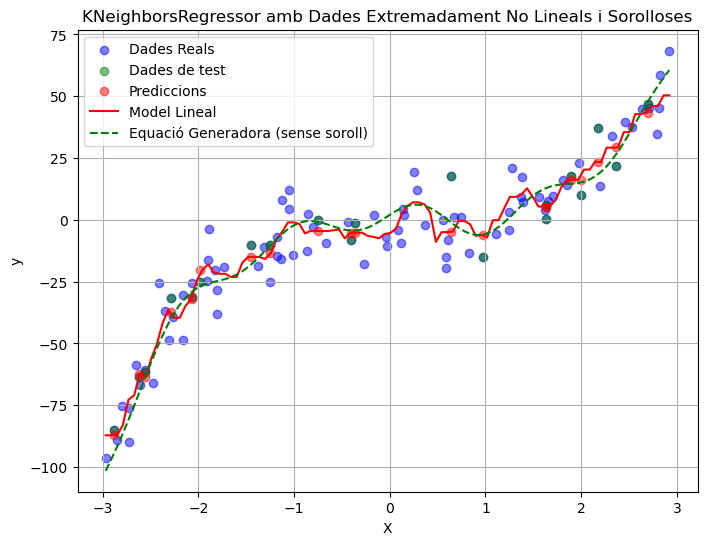

Gràfic: Ajust del model de regressió lineal a les dades reals (dades altament no lineals i sorolloses).

Mètriques del Model Lineal:
  MSE: 248.2732
  RMSE: 15.7567
  R²: 0.7662


In [9]:
# Importar les biblioteques necessàries
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generar dades altament no lineals i extremadament sorolloses
np.random.seed(42)  # Fixar una llavor per a la reproductibilitat
X = np.random.uniform(-3, 3, size=(100, 1))  # Generar valors uniformes entre -3 i 3

# Introduir termes complexos no lineals amb soroll significatiu
y = 3 * X**3 - 2 * X**2 + 5 * np.sin(5 * X) + 2 * np.cos(3 * X) + np.random.normal(0, 10, size=X.shape)

# Imprimir l'equació utilitzada per a generar les dades
print("Equació utilitzada per a generar les dades: y = 3X³ - 2X² + 5sin(5X) + 2cos(3X) + soroll")

# Dividir les dades en conjunts d'entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # 80% entrenament, 20% prova

# Creación de un regresor k-NN (k vecinos más cercanos)
reg = KNeighborsRegressor(n_neighbors=5)
# Entrenamiento del regresor
reg.fit(X, y)
# Predicción para datos de entrenamiento
y_pred = reg.predict(X_test)
# Coeficiente de determinación
r2_score = r2_score(y_test, y_pred)
print('Coef. de determinación R2: {r2_sc}'.format(r2_sc=r2_score))
# Gráfica de modelo de regresión sobre scatterplot de datos
# Visualitzar les dades reals i la línia ajustada
plt.figure(figsize=(8, 6))  # Crear una figura amb una grandària específica
plt.scatter(X, y, color='blue', alpha=0.5, label="Dades Reals")  # Graficar els punts de dades originals
plt.scatter(X_test, y_test, color='green', alpha=0.5, label="Dades de test")  # Graficar els punts
plt.scatter(X_test, y_pred, color='red', alpha=0.5, label="Prediccions")  # Graficar els punts de predicció
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) 
y_range_pred = reg.predict(X_range)  # Preveure valors de Y per al rang continu
plt.plot(X_range, y_range_pred, color="red", label="Model KNeighborsRegressor")  # Graficar la línia del model
y_generated_range = 3 * X_range**3 - 2 * X_range**2 + 5 * np.sin(5 * X_range) + 2 * np.cos(3 * X_range)
plt.plot(X_range, y_generated_range, color='green', linestyle='--', label='Equació Generadora (sense soroll)')
plt.title("KNeighborsRegressor amb Dades Extremadament No Lineals i Sorolloses")  # Títol del gràfic
plt.xlabel("X")  # Etiqueta de l'eix X
plt.ylabel("y")  # Etiqueta de l'eix Y
plt.legend()
plt.grid()
plt.show()

# Afegir un títol per a presentar el contingut del gràfic
print("Gràfic: Ajust del model de regressió lineal a les dades reals (dades altament no lineals i sorolloses).")

# Mostrar mètriques de rendiment
print("\nMètriques del Model Lineal:")
print(f"  MSE: {mse:.4f}")  # Imprimir l'MSE amb 4 decimals
print(f"  RMSE: {rmse:.4f}")  # Imprimir l'RMSE amb 4 decimals
print(f"  R²: {r2:.4f}")  # Imprimir l'R² amb 4 decimals

## Comparativa d'altres regressions

El següent codi avalua diversos algorismes de regressió. Es pot observar una diferència clau entre els models: aquells que, com la regressió polinòmica, transformen les característiques per permetre que un model lineal s'ajusti a relacions no lineals; i aquells, com el Random Forest, que construeixen prediccions basades en un conjunt de regles decisions.

Segons les mètriques obtingudes, la regressió polinòmica de grau 3 i el Random Forest destaquen com els models amb millor rendiment, tot i que per raons diferents. La regressió polinòmica aconsegueix un ajust excel·lent (amb un R² de 0.942) mitjançant una corba suau que capta de manera efectiva la tendència no lineal subjacent de les dades. D'altra banda, el Random Forest, amb un R² de 0.932, aproxima la funció amb segments que s'adapten bé a les dades, detectant les seves irregularitats. Tot i que els models basats en arbres poden ser propensos al sobreajust, en aquest cas particular, el Random Forest generalitza molt bé al conjunt de prova, demostrant una capacitat robusta per capturar la complexitat de les dades sense una penalització significativa per sobreajust respecte al model polinòmic en aquest conjunt de dades.

Altres algorismes provats inclouen:

*   **Models Lineals i Regularitzats:** La Regressió Lineal Simple, SGD, Ridge, Lasso, Elastic Net, LARS i Bayesian Ridge, tot i les seves variants de regularització, van mostrar un rendiment limitat per a aquestes dades no lineals, amb un R² consistentment al voltant de 0.76. Això subratlla la incapacitat dels models lineals per capturar relacions intrínsecament no lineals sense una transformació prèvia de les característiques.

*   **Màquines de Vectors de Suport (SVR):** Dins dels models SVR, es van provar diferents kernels. L'SVR amb kernel lineal i RBF (Radial Basis Function) van obtenir resultats inferiors, amb un R² de 0.678 i 0.356 respectivament, indicant que no són els més adequats per a la complexitat de les dades presentades. No obstant, l'SVR amb kernel polinòmic va millorar significativament, arribant a un R² de 0.874, demostrant que la transformació polinòmica pot ajudar aquest tipus de models a adaptar-se millor a les no linealitats.

*   **Models d'Ensamble:** A més del Random Forest, el **Gradient Boosting** (R² de 0.929) també va oferir un rendiment molt sòlid, reforçant la idea que els models basats en arbres són eficaços per a dades complexes. El **Voting Regressor**, que combina les prediccions de múltiples models, va obtenir un R² de 0.880, demostrant la robustesa d'integrar diferents perspectives per millorar la predicció general.

En resum, per a dades amb patrons no lineals i soroll, els models que intrínsecament poden capturar aquesta complexitat (com la regressió polinòmica o els models d'ensamble basats en arbres) superen clarament els models lineals simples o variants d'SVR amb kernels menys adaptats.

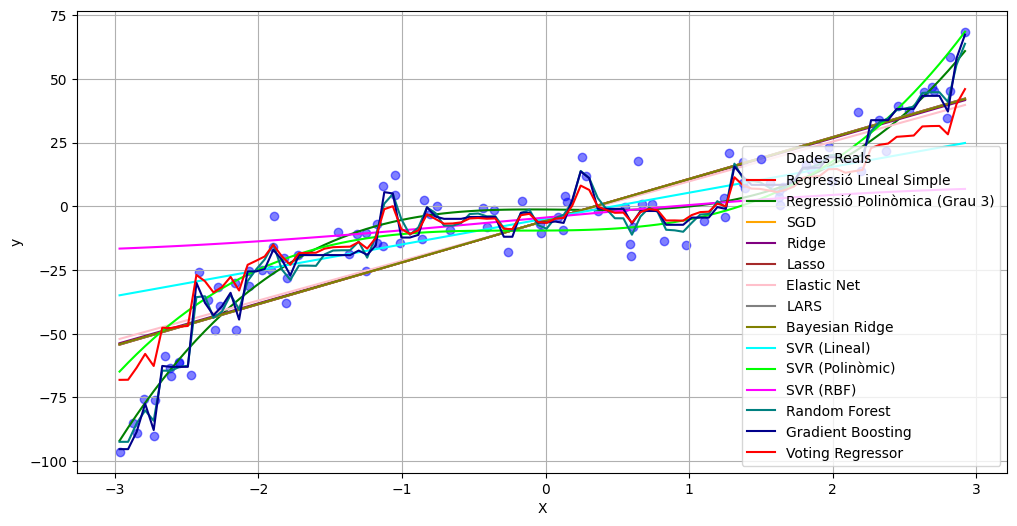


Resultats dels models de regressió (ordenats per R²):
                        Model        MSE      RMSE       R²
Regressió Polinòmica (Grau 3)  61.090895  7.816066 0.942471
                Random Forest  71.814182  8.474325 0.932373
            Gradient Boosting  75.290548  8.677013 0.929099
             Voting Regressor 126.871410 11.263721 0.880526
              SVR (Polinòmic) 133.286832 11.544992 0.874485
                  Elastic Net 243.540637 15.605789 0.770659
                        Ridge 246.651135 15.705131 0.767730
               Bayesian Ridge 247.714545 15.738950 0.766729
                        Lasso 247.785165 15.741193 0.766662
                          SGD 248.084740 15.750706 0.766380
      Regressió Lineal Simple 248.273153 15.756686 0.766203
                         LARS 248.273153 15.756686 0.766203
                 SVR (Lineal) 341.490322 18.479457 0.678421
                    SVR (RBF) 683.715466 26.147953 0.356150


In [12]:
# Importar les biblioteques necessàries
import numpy as np
import pandas as pd
from sklearn.linear_model import (LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, Lars, BayesianRidge)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generar dades altament no lineals i extremadament sorolloses
np.random.seed(42)
X = np.random.uniform(-3, 3, size=(100, 1))  # Generar valors uniformes entre -3 i 3
y = 3 * X**3 - 2 * X**2 + 5 * np.sin(5 * X) + 2 * np.cos(3 * X) + np.random.normal(0, 10, size=X.shape)

# Dividir les dades en conjunts d'entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar les dades per a algorismes sensibles a l'escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Configurar els models a avaluar
models = {
    "Regressió Lineal Simple": LinearRegression(),
    "Regressió Polinòmica (Grau 3)": PolynomialFeatures(degree=3),
    "SGD": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "LARS": Lars(),
    "Bayesian Ridge": BayesianRidge(),
    "SVR (Lineal)": SVR(kernel="linear", C=1.0),
    "SVR (Polinòmic)": SVR(kernel="poly", C=1.0, degree=3),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0, gamma=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Afegir model ensemble amb vot
voting_regressor = VotingRegressor(estimators=[
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("SVR RBF", SVR(kernel="rbf", C=1.0, gamma=0.1)),
])
models["Voting Regressor"] = voting_regressor

results = []  # Llista per a emmagatzemar els resultats de cada model

plt.figure(figsize=(12, 6))
plt.scatter(X, y, color="blue", alpha=0.5, label="Dades Reals")
colors_basics = ['red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'lime', 'magenta', 'teal', 'darkblue']

for i, (name, model) in enumerate(models.items()): # Added enumerate to get index 'i'
    if name == "Regressió Polinòmica (Grau 3)":
        # Preprocessar característiques polinòmiques
        poly = PolynomialFeatures(degree=3)
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)
        regressor = LinearRegression()
        regressor.fit(X_train_poly, y_train)
        y_pred = regressor.predict(X_test_poly)
    else:
        # Entrenar els altres models directament
        model.fit(X_train_scaled, y_train.ravel())
        y_pred = model.predict(X_test_scaled)

    # Calcular mètriques de rendiment
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Emmagatzemar resultats
    results.append((name, mse, rmse, r2))

    # Visualitzar l'ajust del model
    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_range_scaled = scaler.transform(X_range)
    if name == "Regressió Polinòmica (Grau 3)":
        X_range_poly = poly.transform(X_range_scaled)
        y_range_pred = regressor.predict(X_range_poly)
    else:
        y_range_pred = model.predict(X_range_scaled)


    plt.plot(X_range, y_range_pred, color=colors_basics[i % len(colors_basics)], label=name) # Modified color assignment
#plt.title(name)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# Crear un DataFrame amb els resultats i ordenar-los per R²
results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R²"]).sort_values(by="R²", ascending=False)

# Imprimir els resultats ordenats
print("\nResultats dels models de regressió (ordenats per R²):")
print(results_df.to_string(index=False))

## Regressió amb més d'una característica



El següent exemple expandeix la comparació de models de regressió a un escenari amb **múltiples característiques**. S'utilitzen 5 característiques (`n_features = 5`) per generar un conjunt de dades sintètiques altament no lineal i sorollós. L'equació de generació de dades inclou termes cúbics, quadràtics, sinus i cosinus aplicats a diferents característiques, juntament amb un terme lineal i soroll significatiu. Aquesta complexitat addicional posa a prova la capacitat de cada model per capturar relacions en un espai dimensional més alt.

Els passos clau són:

1.  **Generació de Dades Multidimensionals:** Es creen 100 mostres amb 5 característiques (`X`) que influeixen en la variable objectiu (`y`) mitjançant una combinació complexa de funcions no lineals i soroll.
2.  **Escalat de Dades:** Donada la sensibilitat de molts algorismes a l'escala de les característiques, s'utilitza `StandardScaler` per normalitzar les dades d'entrenament i prova.
3.  **Comparació de Models:** Es reprodueix la mateixa bateria de models de regressió provats anteriorment (models lineals, regularitzats, polinòmic, SVR, basats en arbres i d'ensemble).
4.  **Avaluació:** Per a cada model, es calculen el MSE, RMSE i R² sobre el conjunt de prova, i els resultats es presenten ordenats per R².

**Anàlisi dels Resultats:**

En aquest escenari amb múltiples característiques i una funció generadora més complexa, s'observen canvis significatius en el rendiment dels models respecte al cas d'una sola característica:

*   **Models Basats en Arbres (Gradient Boosting i Random Forest):** Aquests models emergeixen com els clars guanyadors, ocupant les primeres posicions amb R² al voltant de 0.80. La seva capacitat per modelar relacions complexes i interaccions entre característiques els fa molt adequats per a aquest tipus de dades multidimensionals i no lineals.

*   **Models Lineals i Regularitzats:** Els models com la Regressió Lineal Simple, Ridge, Lasso, Elastic Net, LARS, SGD i Bayesian Ridge mostren un rendiment similar entre 0.77 i 0.775. Tot i ser robustos en la seva categoria, la seva naturalesa lineal inherent limita la seva capacitat per ajustar-se completament a la complexa funció no lineal que genera les dades, fins i tot amb múltiples característiques.

*   **Regressió Polinòmica (Grau 3):** A diferència del cas d'una sola característica on va ser el millor, en aquest escenari multidimensional, el seu rendiment cau significativament a un R² de 0.627. Això es deu a que `PolynomialFeatures` genera un nombre molt gran de noves característiques (incloent termes d'interacció) quan s'aplica a dades amb moltes dimensions, la qual cosa pot portar a un sobreajust, inestabilitat numèrica i una menor capacitat de generalització si la veritable relació no és directament polinòmica en totes les interaccions o si el grau triat és massa alt per a l'estructura de dades real.

*   **Màquines de Vectors de Suport (SVR):** El rendiment dels models SVR continua sent inferior en general, especialment l'SVR (RBF) i l'SVR (Polinòmic) amb R² molt baixos. L'SVR (Lineal) obté un R² de 0.711, que, tot i ser millor que els altres SVR, està per sota dels models basats en arbres i molts dels lineals regularitzats.

*   **Voting Regressor:** El `Voting Regressor` també veu el seu rendiment disminuït, ubicant-se amb un R² de 0.710. Això és atribuïble a la inclusió de regressors amb rendiment baix com l'SVR (RBF) dins del seu conjunt d'estimators.

En conclusió, aquest exemple il·lustra que en entorns amb dades no lineals i múltiples característiques, els models basats en arbres com **Gradient Boosting** i **Random Forest** són sovint les opcions més efectives, mentre que els models que no gestionen la no linealitat de manera intrínseca (models lineals) o que generen massa complexitat amb moltes dimensions (com la regressió polinòmica sense una selecció de característiques o regularització adequada) poden tenir dificultats.

In [13]:
# Importar les biblioteques necessàries
import numpy as np
import pandas as pd
from sklearn.linear_model import (LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, Lars, BayesianRidge)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generar dades amb múltiples característiques (5 característiques en aquest cas)
np.random.seed(42)
n_features = 5
X = np.random.uniform(-3, 3, size=(100, n_features))  # Generar valors uniformes entre -3 i 3 per a 5 característiques
y = (
    3 * X[:, 0]**3 - 2 * X[:, 1]**2 + 5 * np.sin(5 * X[:, 2]) +
    2 * np.cos(3 * X[:, 3]) + 0.5 * X[:, 4] + np.random.normal(0, 10, size=(X.shape[0],))
)

#print(X.shape,y.shape)

# Dividir les dades en conjunts d'entrenament i prova
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar les dades per a algorismes sensibles a l'escala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Configurar els models a avaluar
models = {
    "Regressió Lineal Simple": LinearRegression(),
    "Regressió Polinòmica (Grau 3)": PolynomialFeatures(degree=3),
    "SGD": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "LARS": Lars(),
    "Bayesian Ridge": BayesianRidge(),
    "SVR (Lineal)": SVR(kernel="linear", C=1.0),
    "SVR (Polinòmic)": SVR(kernel="poly", C=1.0, degree=3),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0, gamma=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Afegir model ensemble amb vot
voting_regressor = VotingRegressor(estimators=[
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("SVR RBF", SVR(kernel="rbf", C=1.0, gamma=0.1)),
])
models["Voting Regressor"] = voting_regressor

results = []  # Llista per a emmagatzemar els resultats de cada model



for name, model in models.items():
    if name == "Regressió Polinòmica (Grau 3)":
        # Preprocessar característiques polinòmiques
        poly = PolynomialFeatures(degree=3)
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)
        regressor = LinearRegression()
        regressor.fit(X_train_poly, y_train)
        y_pred = regressor.predict(X_test_poly)
    else:
        # Entrenar els altres models directament
        model.fit(X_train_scaled, y_train.ravel())
        y_pred = model.predict(X_test_scaled)

    # Calcular mètriques de rendiment
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Emmagatzemar resultats
    results.append((name, mse, rmse, r2))


# Crear un DataFrame amb els resultats i ordenar-los per R²
results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R²"]).sort_values(by="R²", ascending=False)

# Imprimir els resultats ordenats
print("\nResultats dels models de regressió (ordenats per R²):")
print(results_df.to_string(index=False))


Resultats dels models de regressió (ordenats per R²):
                        Model        MSE      RMSE       R²
            Gradient Boosting 163.647705 12.792486 0.799692
                Random Forest 167.151534 12.928710 0.795403
               Bayesian Ridge 184.183436 13.571420 0.774556
                        Ridge 184.506114 13.583303 0.774161
                  Elastic Net 184.842159 13.595667 0.773749
      Regressió Lineal Simple 185.201586 13.608879 0.773310
                         LARS 185.201586 13.608879 0.773310
                          SGD 185.492323 13.619557 0.772954
                        Lasso 187.330302 13.686866 0.770704
                 SVR (Lineal) 235.826293 15.356637 0.711344
             Voting Regressor 236.714932 15.385543 0.710256
Regressió Polinòmica (Grau 3) 304.422114 17.447697 0.627381
              SVR (Polinòmic) 633.159916 25.162669 0.225000
                    SVR (RBF) 702.810623 26.510576 0.139746


Com que tenim 5 característiques i és impossible representar-les en 2 dimensions les gràfiques perden el sentit. Però podem fer gràfiques que ens donen certa informació al voltant del dataset.

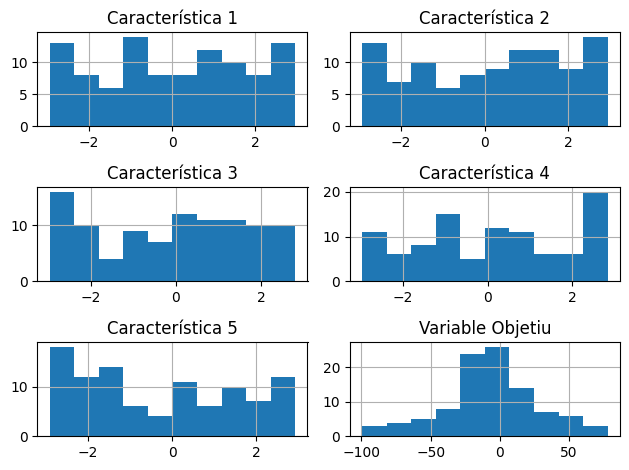

In [14]:
df = pd.DataFrame(X, columns=[f'Característica {i+1}' for i in range(n_features)])
df['Variable Objetiu'] = y
df.hist()
plt.tight_layout()
plt.show()

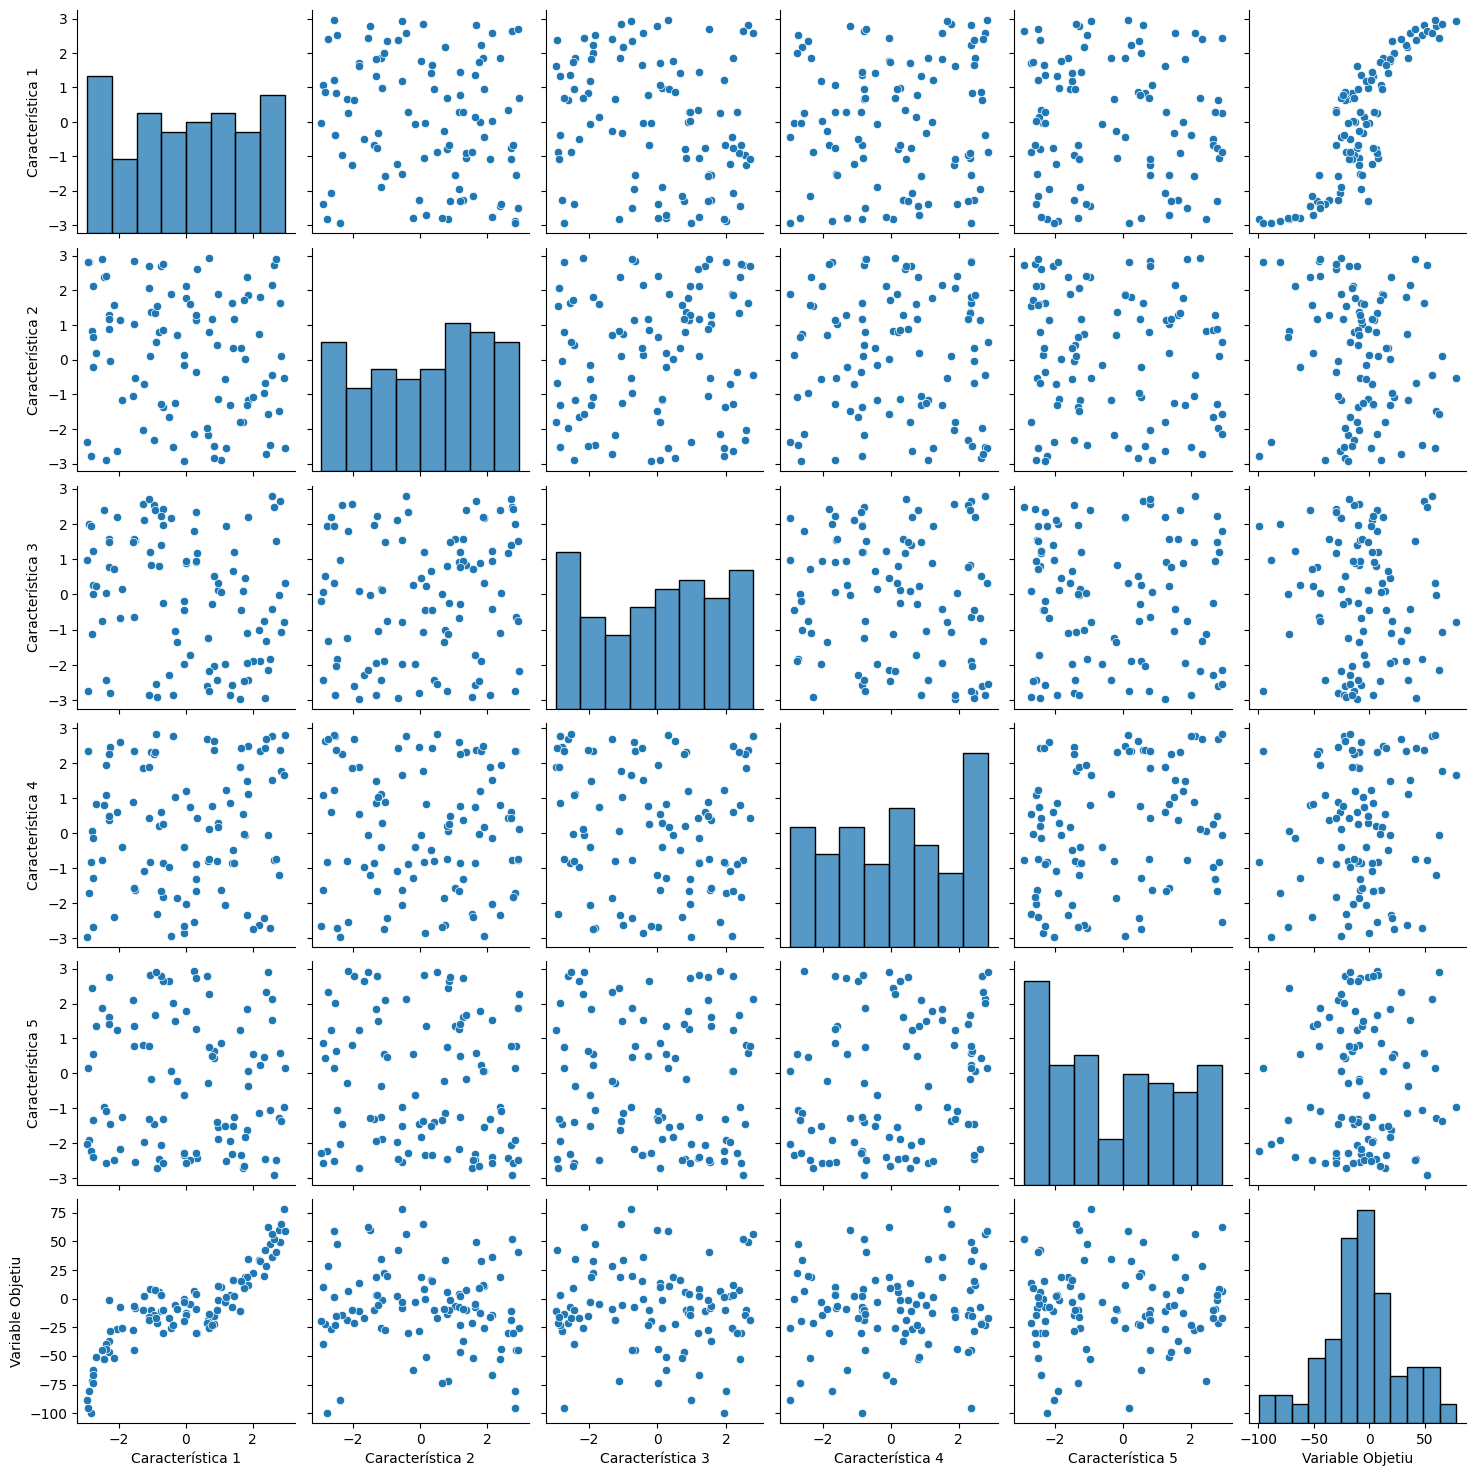

In [15]:
import seaborn as sns

sns.pairplot(data=df)

En analitzar els histogrames i el pairplot, podem observar el següent:

**Què podem concloure:**

*   **Distribució de característiques individuals:** Els histogrames de la diagonal mostren que les característiques individuals (`Característica 1` a `Característica 5`) presenten una distribució uniforme, tal com s'han generat. La `Variable Objectiu` mostra una distribució que s'aproxima a la normal, confirmant que les contribucions de les diferents variables aleatòries que la formen es compensen per aproximar aquesta forma.
*   **Relacions bivariades:** Els gràfics de dispersió entre parells de característiques revelen si hi ha relacions lineals, no lineals o cap relació aparent entre elles. En aquest cas, les relacions són majoritàriament aleatòries o feblement no lineals a primera vista, com s'espera de característiques generades de forma independent per a una funció complexa.
*   **Patrons generals:** Encara que no s'observen correlacions lineals fortes, les visualitzacions poden suggerir la presència de patrons o agrupacions en les dades.



<Axes: >

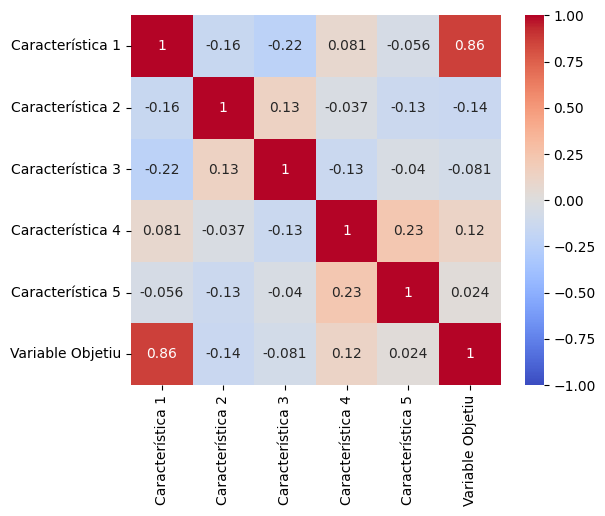

In [16]:
sns.heatmap(df.corr(), square=True, annot=True, vmin=-1, vmax=1, cmap='coolwarm')

En la matriu de correlacions, efectivament, **no detectem cap correlació lineal rellevant** individual entre les variables característiques ni amb la variable objectiu. Els valors de correlació són propers a zero o molt baixos, el que indica una absència de relacions lineals directes.

La matriu de correlacions (que mesura la correlació de Pearson) està dissenyada per detectar relacions lineals. Atès que les dades van ser generades amb una funció altament no lineal i complexa (`y = 3 * X[:, 0]**3 - 2 * X[:, 1]**2 + 5 * np.sin(5 * X[:, 2]) + 2 * np.cos(3 * X[:, 3]) + 0.5 * X[:, 4] + soroll`), és completament esperable que no hi hagi correlacions lineals fortes. Les característiques individuals (`Característica 1` a `Característica 5`) també es van generar de forma independent, de manera que les correlacions entre elles també haurien de ser properes a zero.

Aquest problema és difícil d'analitzar amb gràfiques que simplifiquen dades multidimensionals a 2D (com els pairplots) o que només capturen la linealitat (com els mapes de calor de correlació de Pearson). Aquestes eines són útils per a una primera inspecció i per detectar problemes evidents de linealitat o multicol·linealitat, però són insuficients per entendre relacions no lineals complexes en alta dimensió.

**Per on es pot continuar:**

*   **Enginyeria de Característiques (Feature Engineering):** Tot i que la regressió polinòmica de grau 3 va tenir dificultats amb múltiples característiques (a causa de l'explosió de dimensions i el possible sobreajust), es podria explorar la creació manual de característiques que reflecteixin millor les relacions no lineals conegudes o sospitades, com ara termes d'interacció específics, transformacions logarítmiques o exponencials, o termes trigonomètrics si la física del problema ho suggereix.

*   **Anàlisi d'Importància de Característiques per a Models No Lineals (XAI):** Un cop entrenats models complexos, utilitzar tècniques d'Intel·ligència Artificial Explicable (XAI) com SHAP (SHapley Additive exPlanations) o Partial Dependence Plots (PDPs) pot ajudar a entendre com cada característica (o la seva interacció) influeix en la predicció del model, fins i tot si la relació no és lineal ni detectable per una correlació simple.

*   **Exploració de l'Espai de Dades amb Reducció de Dimensionalitat No Lineal:** Tècniques com t-SNE (t-distributed Stochastic Neighbor Embedding) o UMAP (Uniform Manifold Approximation and Projection) poden visualitzar estructures d'alta dimensionalitat en 2D o 3D, tot i que la seva interpretació per a la regressió pot ser més complexa que per a la classificació.